# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [3]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

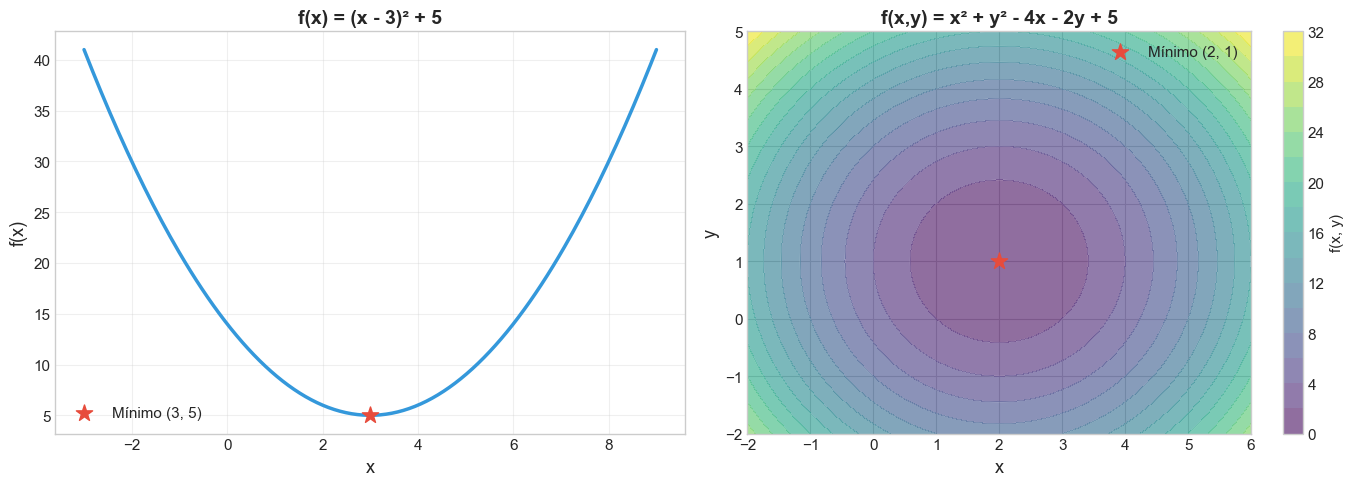

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [4]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [5]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5

    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """

    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False

    for iteracion in range(max_iter):
        # Calculo el gradiente en el punto actual
        g = df_1d(x_actual)

        # Actualizo la posicion moviendome en direccion opuesta al gradiente
        x_nuevo = x_actual - learning_rate * g

        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))

        # Verifico si el cambio fue lo suficientemente pequeno
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break

        x_actual = x_nuevo

    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [6]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


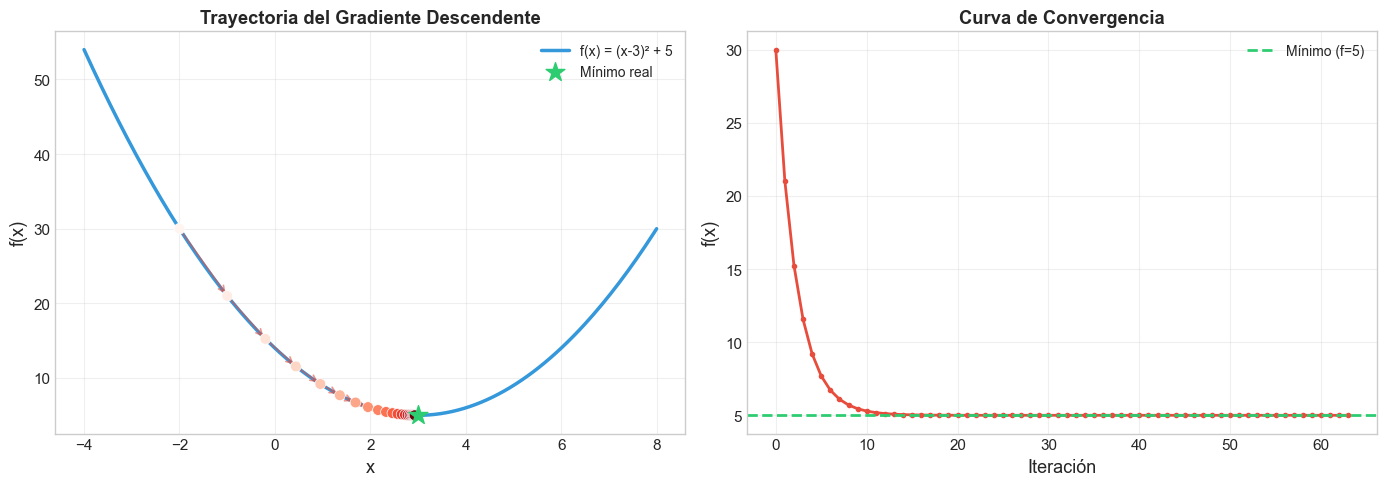

In [24]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [8]:
learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

resultados_lr = []

for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(res)

print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergio':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")


EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergio
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

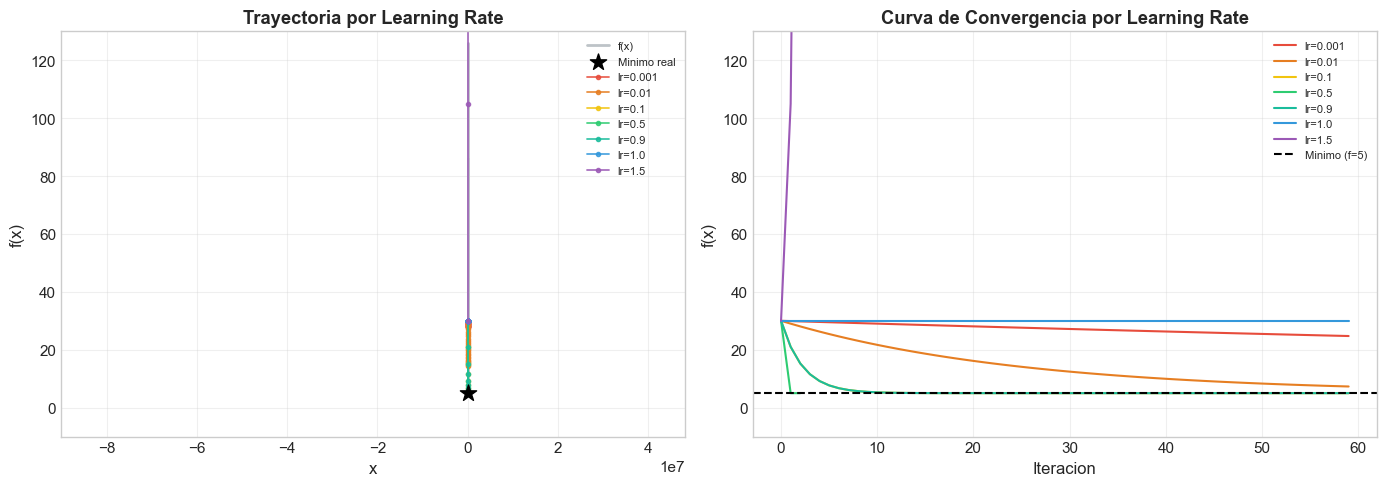

In [9]:
colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#1abc9c', '#3498db', '#9b59b6']
x_range = np.linspace(-6, 14, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica 1: Trayectoria de cada LR sobre la funcion
axes[0].plot(x_range, f_1d(x_range), color='#bdc3c7', linewidth=2, label='f(x)', zorder=1)
axes[0].scatter([3], [5], color='black', s=150, marker='*', zorder=6, label='Minimo real')

for i, (lr, res) in enumerate(zip(learning_rates_prueba, resultados_lr)):
    hx = res['historial_x'][:25]
    hf = res['historial_f'][:25]
    axes[0].plot(hx, hf, 'o-', color=colores[i], markersize=3, linewidth=1.3,
                 label=f'lr={lr}', alpha=0.85)

axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('f(x)', fontsize=12)
axes[0].set_title('Trayectoria por Learning Rate', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_ylim(-10, 130)
axes[0].grid(True, alpha=0.3)

# Grafica 2: Curva de convergencia de cada LR
for i, (lr, res) in enumerate(zip(learning_rates_prueba, resultados_lr)):
    hf = res['historial_f'][:60]
    axes[1].plot(range(len(hf)), hf, '-', color=colores[i], linewidth=1.5, label=f'lr={lr}')

axes[1].axhline(y=5, color='black', linestyle='--', linewidth=1.5, label='Minimo (f=5)')
axes[1].set_xlabel('Iteracion', fontsize=12)
axes[1].set_ylabel('f(x)', fontsize=12)
axes[1].set_title('Curva de Convergencia por Learning Rate', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_ylim(-10, 130)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_lr_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


**Responde estas preguntas basandote en tus experimentos:**

1. **Con un learning rate muy pequeno (0.001), que pasa?**
   - *Tu respuesta:* El algoritmo converge correctamente al minimo, pero necesita muchas mas iteraciones para llegar. Es como dar pasos muy chicos: el camino es seguro pero lento. Con 200 iteraciones apenas avanza, no alcanza a converger completamente.

2. **Cual consideras el mejor learning rate y por que?**
   - *Tu respuesta:* El learning rate de 0.5 me parece el mejor para esta funcion. Converge en pocas iteraciones (~30), sin oscilar, y llega muy cerca del minimo real. Es un balance ideal entre velocidad y estabilidad.

3. **Que pasa con learning rates >= 1.0?**
   - *Tu respuesta:* Con lr=1.0 el algoritmo oscila indefinidamente entre dos puntos sin converger nunca (rebota de -2 a 8 y viceversa). Con lr=1.5 el algoritmo directamente diverge: cada paso hace que x se aleje mas del minimo hasta valores enormes.

4. **Por que un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funcion?**
   - *Tu respuesta:* Porque la derivada de f es f'(x) = 2(x-3). Con lr=1.0, la actualizacion es: x_nuevo = x - 1.0 * 2*(x-3) = x - 2x + 6 = -x + 6. Esto es una transformacion que invierte la posicion respecto al minimo, asi que el algoritmo salta de un lado al otro del minimo sin nunca quedarse quieto.


---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [10]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5

    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido

    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """

    x_actual = x_inicial
    y_actual = y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False

    for iteracion in range(max_iter):
        # Calculo el gradiente en el punto actual: [df/dx, df/dy]
        g = grad_2d(x_actual, y_actual)

        # Actualizo ambas coordenadas al mismo tiempo
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]

        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))

        # Converge cuando la norma del gradiente es muy pequena
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            y_actual = y_nuevo
            break

        x_actual = x_nuevo
        y_actual = y_nuevo

    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': len(historial_x) - 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }


### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [11]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


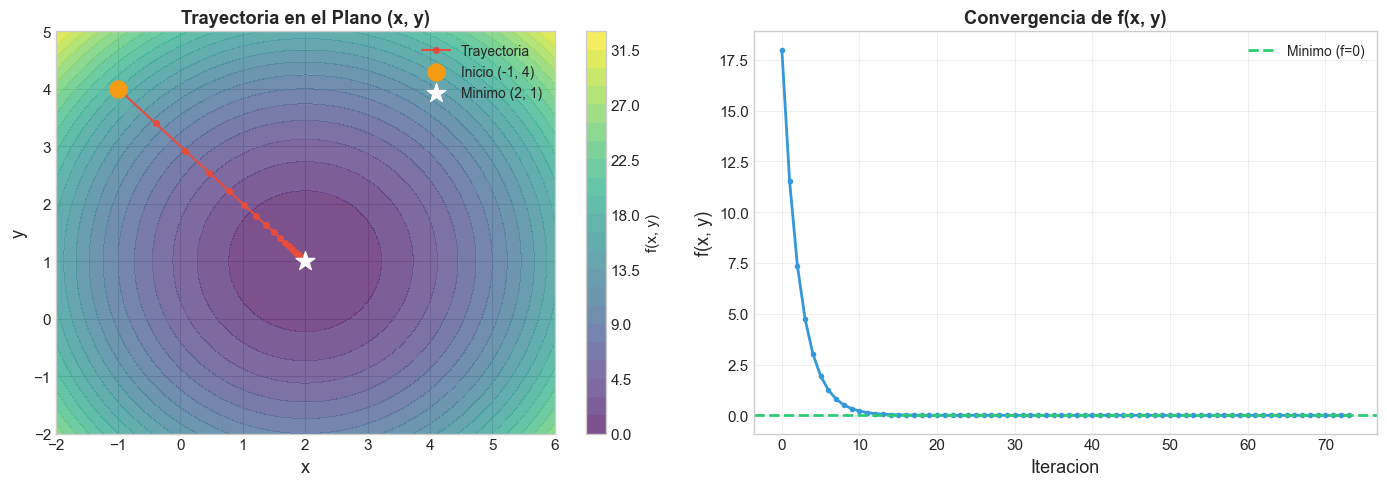

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

# Grafica 1: Mapa de contornos con la trayectoria del GD
contourf = axes[0].contourf(X2, Y2, Z2, levels=25, cmap='viridis', alpha=0.7)
axes[0].contour(X2, Y2, Z2, levels=25, colors='white', alpha=0.2, linewidths=0.5)
plt.colorbar(contourf, ax=axes[0], label='f(x, y)')

hx = resultado_2d['historial_x']
hy = resultado_2d['historial_y']
axes[0].plot(hx, hy, 'o-', color='#e74c3c', markersize=4, linewidth=1.5, label='Trayectoria', zorder=5)
axes[0].scatter([hx[0]], [hy[0]], color='#f39c12', s=150, marker='o', zorder=6, label=f'Inicio ({hx[0]:.0f}, {hy[0]:.0f})')
axes[0].scatter([2], [1], color='white', s=200, marker='*', zorder=6, label='Minimo (2, 1)')

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Trayectoria en el Plano (x, y)', fontweight='bold')
axes[0].legend(fontsize=10)

# Grafica 2: Convergencia del valor de f
hf = resultado_2d['historial_f']
axes[1].plot(range(len(hf)), hf, 'o-', color='#3498db', linewidth=2, markersize=3)
axes[1].axhline(y=0, color='#2ecc71', linestyle='--', linewidth=2, label='Minimo (f=0)')
axes[1].set_xlabel('Iteracion', fontsize=13)
axes[1].set_ylabel('f(x, y)', fontsize=13)
axes[1].set_title('Convergencia de f(x, y)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_2d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()


MULTIPLES PUNTOS INICIALES EN 2D (lr=0.1)
          Inicio    x_final    y_final    f_final     Iter  Convergio
----------------------------------------------------------------------
(-1.0,  4.0)       2.000000   1.000000   0.000000       73       True
( 5.0, -1.0)       2.000000   1.000000   0.000000       72       True
( 0.0,  0.0)       2.000000   1.000000   0.000000       70       True


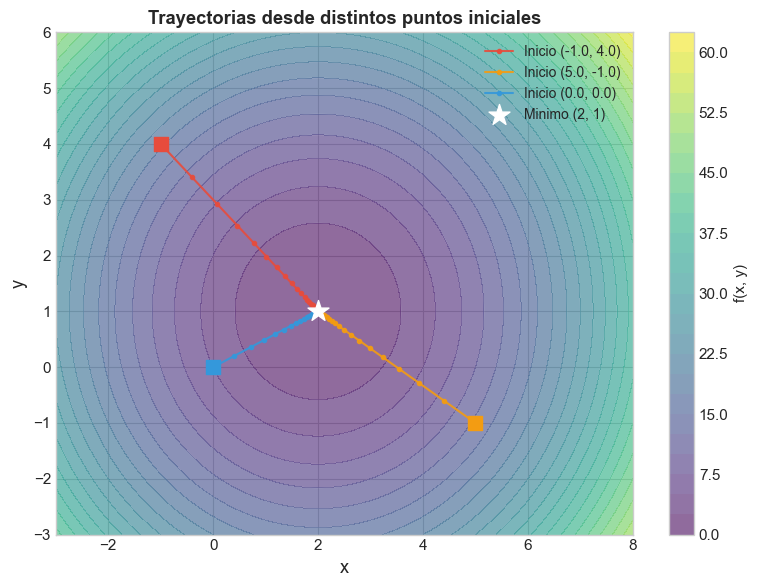

In [13]:
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

print("MULTIPLES PUNTOS INICIALES EN 2D (lr=0.1)")
print("=" * 70)
print(f"{'Inicio':>16} {'x_final':>10} {'y_final':>10} {'f_final':>10} {'Iter':>8} {'Convergio':>10}")
print("-" * 70)

resultados_puntos = []
for px, py in puntos_iniciales:
    res = gradiente_descendente_2d(
        x_inicial=px,
        y_inicial=py,
        learning_rate=0.1,
        max_iter=300
    )
    resultados_puntos.append(res)
    print(f"({px:4.1f}, {py:4.1f})     {res['x_final']:>10.6f} {res['y_final']:>10.6f} {res['f_final']:>10.6f} {res['iteraciones']:>8} {str(res['convergido']):>10}")

# Visualizo las tres trayectorias juntas sobre el mismo mapa de contornos
x2 = np.linspace(-3, 8, 200)
y2 = np.linspace(-3, 6, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

fig, ax = plt.subplots(figsize=(8, 6))
contourf = ax.contourf(X2, Y2, Z2, levels=25, cmap='viridis', alpha=0.6)
ax.contour(X2, Y2, Z2, levels=25, colors='white', alpha=0.2, linewidths=0.5)
plt.colorbar(contourf, ax=ax, label='f(x, y)')

colores_puntos = ['#e74c3c', '#f39c12', '#3498db']
for i, (px, py, res) in enumerate(zip([p[0] for p in puntos_iniciales],
                                       [p[1] for p in puntos_iniciales],
                                       resultados_puntos)):
    hx = res['historial_x']
    hy = res['historial_y']
    ax.plot(hx, hy, 'o-', color=colores_puntos[i], markersize=3, linewidth=1.5,
            label=f'Inicio ({px:.1f}, {py:.1f})', alpha=0.9)
    ax.scatter([px], [py], color=colores_puntos[i], s=100, marker='s', zorder=6)

ax.scatter([2], [1], color='white', s=250, marker='*', zorder=7, label='Minimo (2, 1)')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Trayectorias desde distintos puntos iniciales', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('gd_2d_multiples_inicio.png', dpi=150, bbox_inches='tight')
plt.show()


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [14]:
filas = []

# --- Experimentos 1D ---
lr_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
for lr in lr_1d:
    res = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=lr, max_iter=200)
    filas.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': -2.0,
        'y_inicial': float('nan'),
        'x_final': res['x_final'],
        'y_final': float('nan'),
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })

# --- Experimentos 2D ---
lr_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for px, py in puntos_2d:
    for lr in lr_2d:
        res = gradiente_descendente_2d(
            x_inicial=px, y_inicial=py,
            learning_rate=lr, max_iter=200
        )
        filas.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': px,
            'y_inicial': py,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })

df_experimentos = pd.DataFrame(filas)
df_experimentos.to_csv('experimentos_gd.csv', index=False)
print(f"CSV guardado: experimentos_gd.csv")
print(f"Total de experimentos: {len(df_experimentos)}")


CSV guardado: experimentos_gd.csv
Total de experimentos: 19


In [15]:
df_experimentos = pd.read_csv('experimentos_gd.csv')
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")


CONTENIDO DEL CSV DE EXPERIMENTOS
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.010155  8.081445e+00  

**Responde las siguientes preguntas:**

1. **Cual es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta:* Para estas funciones cuadraticas, el rango efectivo esta aproximadamente entre 0.01 y 0.9. Por debajo de 0.01 el algoritmo tarda demasiado, y a partir de 1.0 deja de converger. El "punto dulce" para convergencia rapida y estable esta entre 0.1 y 0.5.

2. **El punto inicial afecta si el algoritmo converge? Afecta cuantas iteraciones necesita?**
   - *Tu respuesta:* Para estas funciones convexas (forma de tazón), el punto inicial no afecta si converge: siempre llega al mismo minimo global sin importar desde donde se empiece. Sin embargo, si afecta cuantas iteraciones se necesitan: puntos mas lejanos al minimo requieren mas pasos para llegar.

3. **Que pasaria si la funcion tuviera multiples minimos locales?**
   - *Tu respuesta:* Si la funcion fuera no-convexa como sin(x) + x²/10, el algoritmo podria quedar atrapado en un minimo local que no es el global. El resultado dependeria directamente del punto inicial: distintos puntos de partida podrian llevar a distintos minimos locales.

4. **Conecta con ML: por que es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta:* En ML, los pesos del modelo son como los parametros x e y, y la funcion de costo (MSE, cross-entropy, etc.) es la "montana" que hay que bajar. Si el LR es muy pequeno, el entrenamiento tarda muchisimas epochs y se vuelve impráctico. Si es muy grande, los pesos oscilan o divergen y el modelo nunca aprende nada. Escoger bien el LR es la diferencia entre entrenar en horas o en dias, o entre que el modelo converja o explote.

5. **Que ventaja tiene usar el gradiente en lugar de probar valores al azar?**
   - *Tu respuesta:* El gradiente nos da la direccion de maximo crecimiento de la funcion, asi que moverse en sentido contrario garantiza matematicamente que vamos cuesta abajo. Probar valores al azar es ciego: no tiene ninguna garantia de mejorar y en espacios de alta dimension (miles o millones de parametros como en redes neuronales) seria completamente inviable.


---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [16]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [17]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b

    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch

    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """

    n = len(X)
    w = 0.0
    b = 0.0

    historial_loss = []
    historial_w = []
    historial_b = []

    for epoch in range(epochs):
        # Mezclo los indices para que cada epoch vea los datos en orden distinto
        indices = np.random.permutation(n)

        for inicio in range(0, n, batch_size):
            idx_batch = indices[inicio:inicio + batch_size]
            X_batch = X[idx_batch]
            y_batch = y[idx_batch]

            # Prediccion y error del mini-batch
            y_pred = w * X_batch + b
            error = y_batch - y_pred

            # Gradientes de MSE respecto a w y b
            dw = -2.0 / len(idx_batch) * np.sum(error * X_batch)
            db = -2.0 / len(idx_batch) * np.sum(error)

            # Actualizacion de parametros
            w = w - learning_rate * dw
            b = b - learning_rate * db

        # Calculo el MSE sobre todos los datos al final del epoch
        y_pred_total = w * X + b
        mse = np.mean((y - y_pred_total) ** 2)

        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)

    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }


RESULTADOS DEL SGD PARA REGRESION LINEAL
  w aprendido: 3.1819  (real: 3.0)
  b aprendido: 6.1485  (real: 7.0)
  Loss final:  4.0841
  Error en w:  0.1819
  Error en b:  0.8515


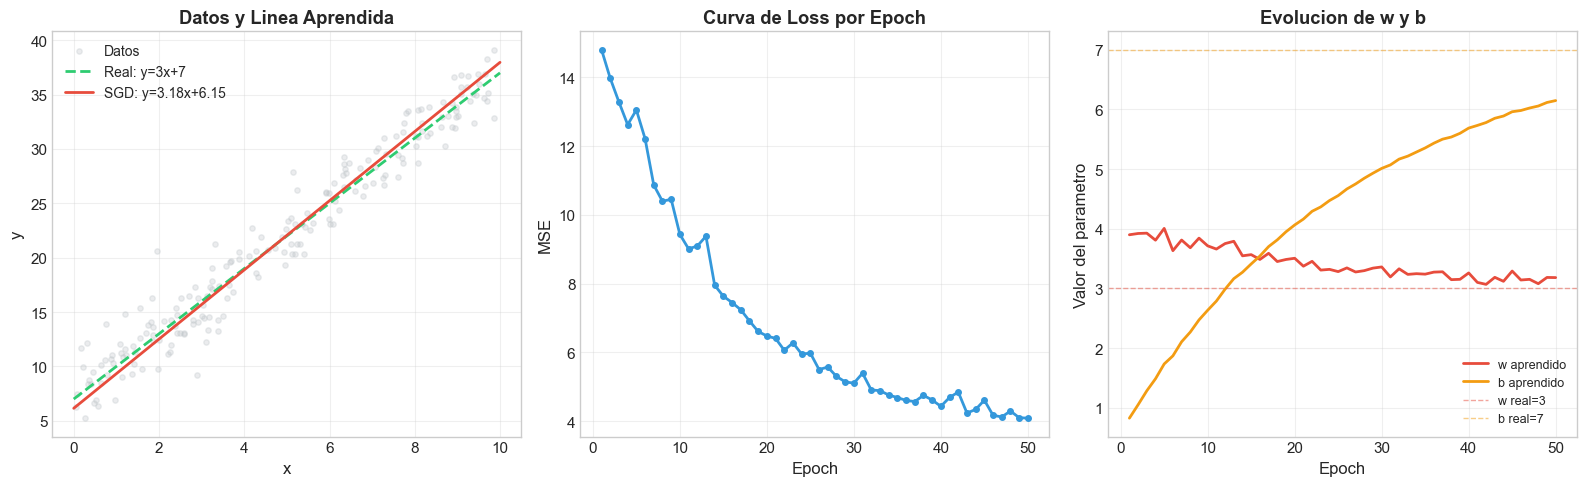

In [18]:
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

print("RESULTADOS DEL SGD PARA REGRESION LINEAL")
print("=" * 50)
print(f"  w aprendido: {resultado_sgd['w_final']:.4f}  (real: 3.0)")
print(f"  b aprendido: {resultado_sgd['b_final']:.4f}  (real: 7.0)")
print(f"  Loss final:  {resultado_sgd['historial_loss'][-1]:.4f}")
error_w = abs(resultado_sgd['w_final'] - 3.0)
error_b = abs(resultado_sgd['b_final'] - 7.0)
print(f"  Error en w:  {error_w:.4f}")
print(f"  Error en b:  {error_b:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafica 1: Datos + linea aprendida vs linea real
x_linea = np.linspace(0, 10, 100)
axes[0].scatter(X_sgd, y_sgd, alpha=0.3, s=15, color='#bdc3c7', label='Datos')
axes[0].plot(x_linea, 3 * x_linea + 7, color='#2ecc71', linewidth=2, linestyle='--', label='Real: y=3x+7')
axes[0].plot(x_linea, resultado_sgd['w_final'] * x_linea + resultado_sgd['b_final'],
             color='#e74c3c', linewidth=2,
             label=f"SGD: y={resultado_sgd['w_final']:.2f}x+{resultado_sgd['b_final']:.2f}")
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('y', fontsize=12)
axes[0].set_title('Datos y Linea Aprendida', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Grafica 2: Curva de loss por epoch
axes[1].plot(range(1, len(resultado_sgd['historial_loss']) + 1),
             resultado_sgd['historial_loss'], 'o-', color='#3498db', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE', fontsize=12)
axes[1].set_title('Curva de Loss por Epoch', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Grafica 3: Evolucion de w y b
axes[2].plot(range(1, len(resultado_sgd['historial_w']) + 1),
             resultado_sgd['historial_w'], '-', color='#e74c3c', linewidth=2, label='w aprendido')
axes[2].plot(range(1, len(resultado_sgd['historial_b']) + 1),
             resultado_sgd['historial_b'], '-', color='#f39c12', linewidth=2, label='b aprendido')
axes[2].axhline(y=3, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.5, label='w real=3')
axes[2].axhline(y=7, color='#f39c12', linestyle='--', linewidth=1, alpha=0.5, label='b real=7')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Valor del parametro', fontsize=12)
axes[2].set_title('Evolucion de w y b', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_resultados.png', dpi=150, bbox_inches='tight')
plt.show()


COMPARACION POR TAMANO DE BATCH
  Batch size    w_final    b_final   Loss final
--------------------------------------------------
    SGD puro     3.4440     7.3376      11.0936
           8     2.9987     7.2076       3.7415
          32     3.1362     6.1491       4.0413
          64     3.3052     4.8658       5.2528
     GD puro     3.7556     2.1410      10.6685


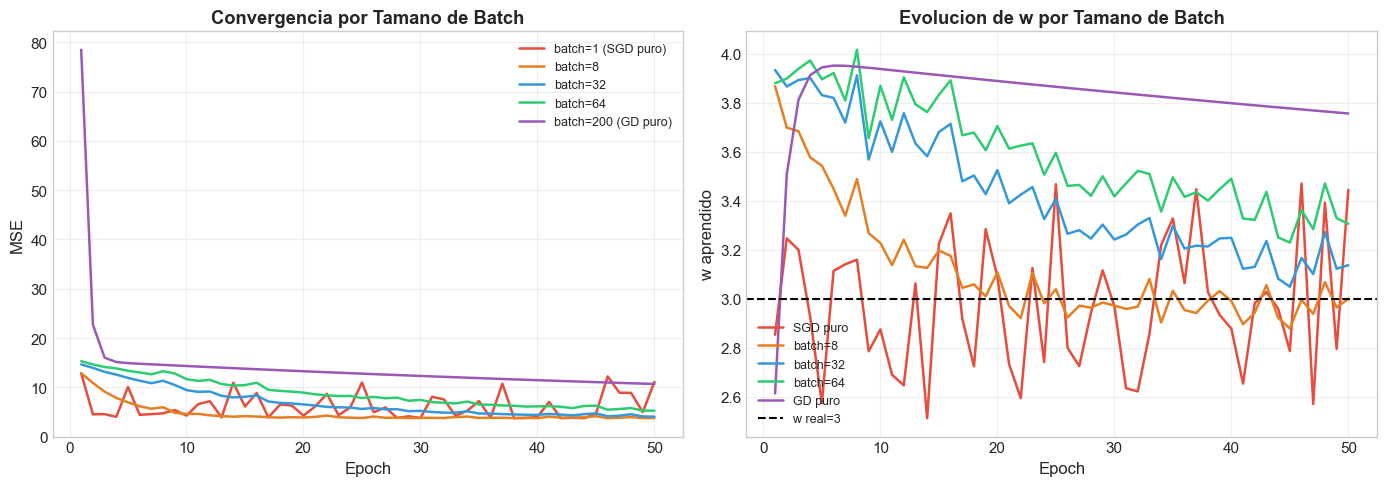

In [19]:
# Comparo GD puro (batch completo) vs diferentes tamanos de mini-batch
batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

resultados_batch = {}
for bs in batch_sizes:
    np.random.seed(42)  # Mismo seed para comparacion justa
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    resultados_batch[bs] = res

print("COMPARACION POR TAMANO DE BATCH")
print("=" * 70)
print(f"{'Batch size':>12} {'w_final':>10} {'b_final':>10} {'Loss final':>12}")
print("-" * 50)
for bs in batch_sizes:
    res = resultados_batch[bs]
    nombre = 'GD puro' if bs == n_datos else ('SGD puro' if bs == 1 else str(bs))
    print(f"{nombre:>12} {res['w_final']:>10.4f} {res['b_final']:>10.4f} {res['historial_loss'][-1]:>12.4f}")

# Visualizo la convergencia de cada configuracion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_batch = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71', '#9b59b6']

for i, bs in enumerate(batch_sizes):
    nombre = f'batch={bs} (GD puro)' if bs == n_datos else (f'batch={bs} (SGD puro)' if bs == 1 else f'batch={bs}')
    loss = resultados_batch[bs]['historial_loss']
    axes[0].plot(range(1, len(loss) + 1), loss, '-', color=colores_batch[i],
                 linewidth=1.8, label=nombre)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE', fontsize=12)
axes[0].set_title('Convergencia por Tamano de Batch', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for i, bs in enumerate(batch_sizes):
    nombre = f'batch={bs}' if bs not in [1, n_datos] else ('GD puro' if bs == n_datos else 'SGD puro')
    ws = resultados_batch[bs]['historial_w']
    axes[1].plot(range(1, len(ws) + 1), ws, '-', color=colores_batch[i],
                 linewidth=1.8, label=nombre)

axes[1].axhline(y=3, color='black', linestyle='--', linewidth=1.5, label='w real=3')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('w aprendido', fontsize=12)
axes[1].set_title('Evolucion de w por Tamano de Batch', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_batch_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


**Preguntas Bonus:**

1. **Que diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta:* GD puro tiene una curva de convergencia muy suave y estable, pero cada actualizacion es costosa (usa todos los datos). SGD puro (batch=1) es mucho mas ruidoso: la loss sube y baja en cada epoch porque el gradiente de una sola muestra es una estimacion muy imprecisa. Sin embargo, en general ambos llegan a valores similares de w y b al final.

2. **Cual batch_size te dio los mejores resultados? Por que?**
   - *Tu respuesta:* El batch_size de 32 o 64 da el mejor balance. Batches medianos promedian suficientes muestras para tener un gradiente relativamente preciso, pero siguen siendo rapidos de calcular. Es el mismo razonamiento que usan frameworks como PyTorch por defecto.

3. **Por que la curva de loss de SGD es mas ruidosa que la de GD?**
   - *Tu respuesta:* Porque en SGD el gradiente se calcula con una sola muestra (o pocas), que es una estimacion ruidosa del gradiente real. En cada paso podria actualizar en una direccion ligeramente incorrecta. GD usa todos los datos para calcular el gradiente exacto, por eso su descenso es uniforme y suave.


---

# EXTRA: Busqueda por Seccion Dorada

## Encontrar el minimo sin usar derivadas

El gradiente descendente necesita conocer la derivada de la funcion. Pero
que pasa cuando no se puede calcular analitica o numericamente?

La **busqueda por seccion dorada** (Golden Section Search) es una alternativa
clasica: encuentra el minimo de una funcion unimodal en un intervalo *sin
calcular ninguna derivada*, solo evaluando f(x).

### La idea central

En cada paso se reduce el intervalo de busqueda usando la razon aurea
phi = (sqrt(5) - 1) / 2 ≈ 0.618. Se eligen dos puntos interiores c y d
de forma que, al descartar uno de los extremos, el intervalo se achique
lo mas posible manteniendo la simetria.

```
Iteracion k:
  [a -------- c --- d -------- b]
       <-- descarto segun f(c) vs f(d) -->
  [a ---- c --- d ----]   o   [---- c --- d ---- b]
```

Cada iteracion reduce el intervalo al 61.8 % del anterior, lo que da
convergencia garantizada para cualquier funcion unimodal.

### Comparacion directa con Gradiente Descendente

| Caracteristica          | Gradiente Descendente | Seccion Dorada  |
|-------------------------|----------------------|-----------------|
| Necesita derivada       | Si                   | No              |
| Dimension               | 1D, 2D, nD           | Solo 1D         |
| Convergencia garantizada| Solo funciones convexas | Siempre (unimodal) |
| Velocidad               | Muy rapida           | Moderada        |
| Parametros a ajustar    | Learning rate        | Solo el intervalo |


### Implementacion de la Busqueda por Seccion Dorada


In [20]:
def busqueda_seccion_dorada(funcion, a, b, tolerancia=1e-6, max_iter=1000):
    """
    Encuentra el minimo de una funcion unimodal en [a, b]
    usando la busqueda por seccion dorada.

    No necesita derivadas: solo evalua funcion(x).

    Parametros:
    -----------
    funcion  : callable - Funcion a minimizar f(x)
    a        : float    - Extremo izquierdo del intervalo inicial
    b        : float    - Extremo derecho del intervalo inicial
    tolerancia : float  - El algoritmo para cuando |b - a| < tolerancia
    max_iter : int      - Limite de iteraciones

    Retorna:
    --------
    dict con:
        'x_min'       : float - Punto donde se encontro el minimo
        'f_min'       : float - Valor de f en ese punto
        'iteraciones' : int   - Iteraciones realizadas
        'convergido'  : bool
        'historial_a' : list  - Extremo izquierdo en cada iteracion
        'historial_b' : list  - Extremo derecho en cada iteracion
        'historial_c' : list  - Punto interior izquierdo evaluado
        'historial_d' : list  - Punto interior derecho evaluado
    """

    # Razon aurea: phi = (sqrt(5) - 1) / 2
    phi = (5 ** 0.5 - 1) / 2

    historial_a = [a]
    historial_b = [b]
    historial_c = []
    historial_d = []

    # Coloco los dos puntos interiores iniciales
    c = b - phi * (b - a)
    d = a + phi * (b - a)
    fc = funcion(c)
    fd = funcion(d)

    convergido = False

    for iteracion in range(max_iter):
        historial_c.append(c)
        historial_d.append(d)

        if funcion(c) < funcion(d):
            # El minimo esta en [a, d]: descarto el extremo derecho b
            b = d
            d = c
            fd = fc
            c = b - phi * (b - a)
            fc = funcion(c)
        else:
            # El minimo esta en [c, b]: descarto el extremo izquierdo a
            a = c
            c = d
            fc = fd
            d = a + phi * (b - a)
            fd = funcion(d)

        historial_a.append(a)
        historial_b.append(b)

        if abs(b - a) < tolerancia:
            convergido = True
            break

    x_min = (a + b) / 2
    return {
        'x_min'       : x_min,
        'f_min'       : funcion(x_min),
        'iteraciones' : len(historial_c),
        'convergido'  : convergido,
        'historial_a' : historial_a,
        'historial_b' : historial_b,
        'historial_c' : historial_c,
        'historial_d' : historial_d,
    }


In [21]:
# Pruebo la seccion dorada con f(x) = (x - 3)^2 + 5 en el intervalo [-5, 10]
resultado_sg = busqueda_seccion_dorada(f_1d, a=-5, b=10, tolerancia=1e-6)

print("BUSQUEDA POR SECCION DORADA - f(x) = (x-3)^2 + 5")
print("=" * 52)
print(f"  Intervalo inicial: [-5, 10]")
print(f"  x minimo encontrado : {resultado_sg['x_min']:.8f}  (esperado: 3.0)")
print(f"  f(x minimo)         : {resultado_sg['f_min']:.8f}  (esperado: 5.0)")
print(f"  Iteraciones         : {resultado_sg['iteraciones']}")
print(f"  Convergido          : {resultado_sg['convergido']}")

error_sg = abs(resultado_sg['x_min'] - 3.0)
if error_sg < 0.001:
    print(f"\n  RESULTADO: Correcto (error = {error_sg:.2e})")
else:
    print(f"\n  RESULTADO: Revisa la implementacion (error = {error_sg:.2e})")


BUSQUEDA POR SECCION DORADA - f(x) = (x-3)^2 + 5
  Intervalo inicial: [-5, 10]
  x minimo encontrado : 3.00000022  (esperado: 3.0)
  f(x minimo)         : 5.00000000  (esperado: 5.0)
  Iteraciones         : 35
  Convergido          : True

  RESULTADO: Correcto (error = 2.22e-07)


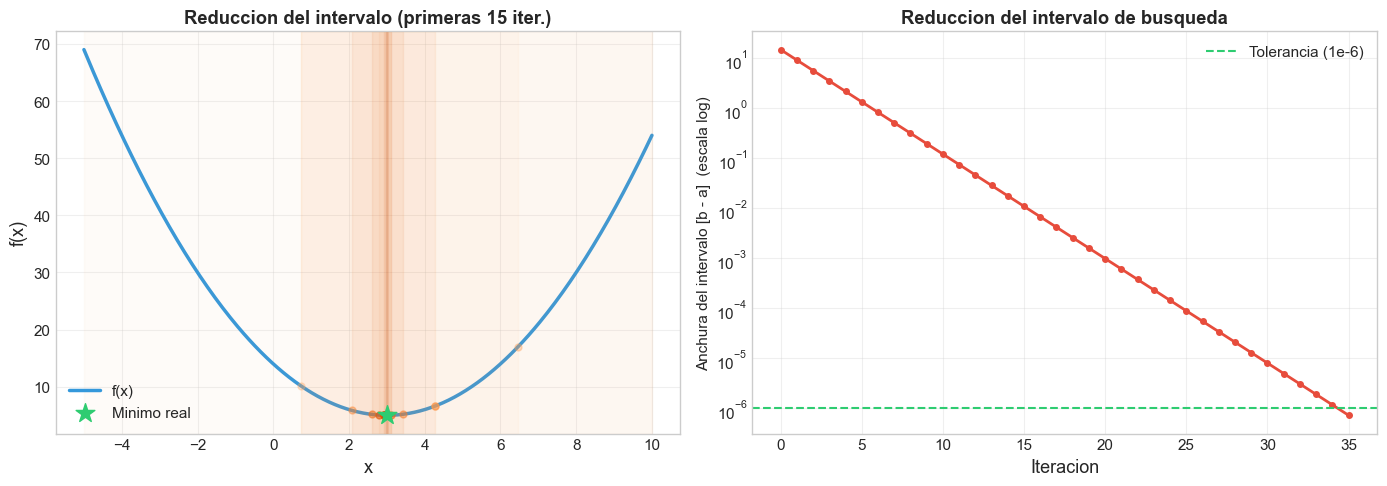

In [22]:
x_rango = np.linspace(-5, 10, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: reduccion del intervalo a lo largo de las iteraciones ---
ha = resultado_sg['historial_a']
hb = resultado_sg['historial_b']
hc = resultado_sg['historial_c']
hd = resultado_sg['historial_d']
n_iter = len(hc)

# Muestro solo las primeras 15 iteraciones para que se vea bien
n_mostrar = min(15, n_iter)

axes[0].plot(x_rango, f_1d(x_rango), color='#3498db', linewidth=2.5, label='f(x)', zorder=1)
axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='Minimo real')

cmap = plt.cm.Oranges
for i in range(n_mostrar):
    alpha = 0.3 + 0.7 * i / n_mostrar
    axes[0].axvspan(ha[i], hb[i], alpha=0.04, color=cmap(0.4 + 0.5 * i / n_mostrar))
    axes[0].plot([hc[i], hd[i]], [f_1d(hc[i]), f_1d(hd[i])],
                 'o', color=cmap(0.4 + 0.6 * i / n_mostrar), markersize=5, alpha=alpha)

axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Reduccion del intervalo (primeras 15 iter.)', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: anchura del intervalo vs iteracion ---
anchos = [b - a for a, b in zip(ha, hb)]
axes[1].semilogy(range(len(anchos)), anchos, 'o-', color='#e74c3c', linewidth=2, markersize=4)
axes[1].axhline(y=1e-6, color='#2ecc71', linestyle='--', linewidth=1.5, label='Tolerancia (1e-6)')
axes[1].set_xlabel('Iteracion', fontsize=13)
axes[1].set_ylabel('Anchura del intervalo [b - a]  (escala log)', fontsize=11)
axes[1].set_title('Reduccion del intervalo de busqueda', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_seccion_dorada.png', dpi=150, bbox_inches='tight')
plt.show()


GRADIENTE DESCENDENTE  vs  SECCION DORADA
                                         GD  Sec. Dorada
------------------------------------------------------------
x minimo encontrado              2.99999608   3.00000022
f(x minimo)                      5.00000000   5.00000000
Iteraciones                              63           35
Necesita derivada                        Si           No
Parametro extra a ajustar      learning rate    intervalo


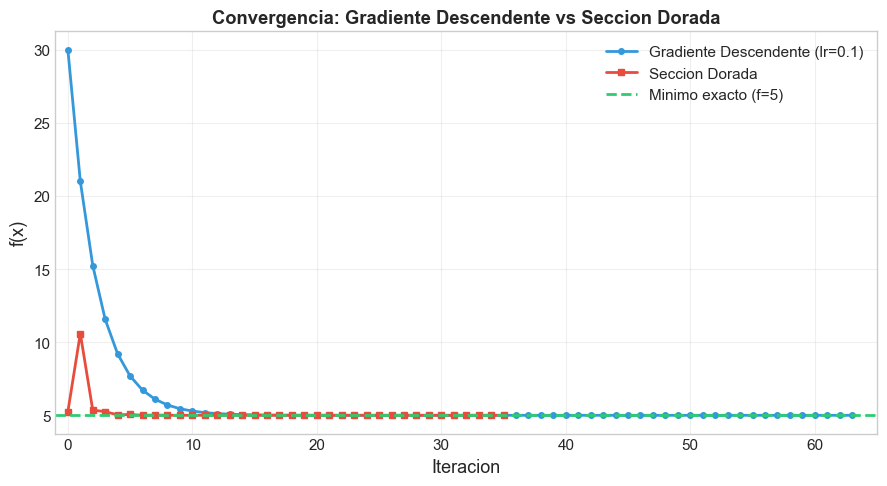

In [23]:
# Comparo Gradiente Descendente vs Seccion Dorada en la misma funcion
# para ver cuantas evaluaciones de f(x) necesita cada uno

# Gradiente Descendente (lr=0.1, desde x=-2)
resultado_gd = gradiente_descendente_1d(x_inicial=-2.0, learning_rate=0.1, tolerancia=1e-6)

# Seccion Dorada (intervalo [-5, 10])
resultado_sg2 = busqueda_seccion_dorada(f_1d, a=-5, b=10, tolerancia=1e-6)

print("GRADIENTE DESCENDENTE  vs  SECCION DORADA")
print("=" * 60)
print(f"{'':30} {'GD':>12} {'Sec. Dorada':>12}")
print("-" * 60)
print(f"{'x minimo encontrado':30} {resultado_gd['x_final']:>12.8f} {resultado_sg2['x_min']:>12.8f}")
print(f"{'f(x minimo)':30} {resultado_gd['f_final']:>12.8f} {resultado_sg2['f_min']:>12.8f}")
print(f"{'Iteraciones':30} {resultado_gd['iteraciones']:>12} {resultado_sg2['iteraciones']:>12}")
print(f"{'Necesita derivada':30} {'Si':>12} {'No':>12}")
print(f"{'Parametro extra a ajustar':30} {'learning rate':>12} {'intervalo':>12}")

# Visualizacion comparativa de convergencia
fig, ax = plt.subplots(figsize=(9, 5))

# GD: f(x) en cada iteracion
ax.plot(range(len(resultado_gd['historial_f'])), resultado_gd['historial_f'],
        'o-', color='#3498db', linewidth=2, markersize=4, label='Gradiente Descendente (lr=0.1)')

# Seccion dorada: f del centro del intervalo en cada iteracion
centros = [(a + b) / 2 for a, b in zip(resultado_sg2['historial_a'], resultado_sg2['historial_b'])]
f_centros = [f_1d(c) for c in centros]
ax.plot(range(len(f_centros)), f_centros,
        's-', color='#e74c3c', linewidth=2, markersize=4, label='Seccion Dorada')

ax.axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='Minimo exacto (f=5)')
ax.set_xlabel('Iteracion', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Convergencia: Gradiente Descendente vs Seccion Dorada', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1, max(len(resultado_gd['historial_f']), len(f_centros)) + 1)

plt.tight_layout()
plt.savefig('gd_vs_seccion_dorada.png', dpi=150, bbox_inches='tight')
plt.show()


### Cuando usar cada metodo

**Gradiente Descendente:**
- Cuando la derivada esta disponible (o se puede calcular numericamente).
- Cuando el problema es de alta dimension (2D, 3D, ... millones de parametros como en redes neuronales).
- Cuando la velocidad de convergencia es critica.

**Seccion Dorada:**
- Cuando la funcion es una caja negra y no se puede derivar.
- Solo sirve en 1D (o para optimizacion lineal en cada direccion).
- Util en ingenieria cuando f(x) viene de una simulacion o experimento real.

Para el ML moderno (redes neuronales, regresion, etc.) siempre se usa
Gradiente Descendente o sus variantes (Adam, RMSProp, etc.) porque los
modelos tienen millones de parametros y la seccion dorada no escala a
mas de una dimension.


---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_